In [ ]:
!pip -q install open_clip_torch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import shutil
import subprocess
from datetime import datetime

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import open_clip

DRIVE_DATASET_ROOT = Path('/content/drive/MyDrive/momentlens_datasets/charades_sta_3fps_v1')
RUNTIME_ROOT = Path('/content/momentlens_train')

DATA_DIR = RUNTIME_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
VIDEO_DIR = DATA_DIR / 'videos'
ANNOT_DIR = DATA_DIR / 'annotations'
SPLIT_DIR = RUNTIME_ROOT / 'splits'
META_DIR = DATA_DIR / 'metadata'
REPORT_DIR = DATA_DIR / 'reports'
CACHE_DIR = DATA_DIR / 'cache'
FRAME_CACHE_DIR = CACHE_DIR / 'frames'

for path in [RAW_DIR, VIDEO_DIR, ANNOT_DIR, SPLIT_DIR, META_DIR, REPORT_DIR, FRAME_CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

def copy_tree(src_dir, dst_dir):
    dst_dir.mkdir(parents=True, exist_ok=True)
    for src in src_dir.rglob('*'):
        if src.is_file():
            dst = dst_dir / src.relative_to(src_dir)
            dst.parent.mkdir(parents=True, exist_ok=True)
            if not dst.exists() or dst.stat().st_size != src.stat().st_size:
                shutil.copy2(src, dst)

copy_tree(DRIVE_DATASET_ROOT / 'data' / 'annotations', ANNOT_DIR)
copy_tree(DRIVE_DATASET_ROOT / 'splits', SPLIT_DIR)
copy_tree(DRIVE_DATASET_ROOT / 'data' / 'metadata', META_DIR)
copy_tree(DRIVE_DATASET_ROOT / 'data' / 'reports', REPORT_DIR)
shutil.copy2(DRIVE_DATASET_ROOT / 'data' / 'dataset_manifest.json', DATA_DIR / 'dataset_manifest.json')

archive_path = DRIVE_DATASET_ROOT / 'raw' / 'videos_3fps_480_noaudio.tar.gz'

extract_marker = VIDEO_DIR / '.extract_done'
if not extract_marker.exists():
    subprocess.run(['tar', '-xzf', str(archive_path), '-C', str(VIDEO_DIR)], check=True)
    extract_marker.write_text(datetime.now().isoformat())

video_files = {}
for path in VIDEO_DIR.rglob('*'):
    if path.suffix.lower() in ['.mp4', '.avi', '.mkv', '.webm']:
        video_files[path.stem] = str(path)

print('runtime root:', RUNTIME_ROOT)
print('artifact root:', DRIVE_DATASET_ROOT)
print('video files found:', len(video_files))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
runtime root: /content/momentlens_train
artifact root: /content/drive/MyDrive/momentlens_datasets/charades_sta_3fps_v1
video files found: 9848


In [ ]:
with open(DATA_DIR / 'dataset_manifest.json', 'r') as f:
    manifest = json.load(f)

with open(ANNOT_DIR / 'train.json', 'r') as f:
    train_data = json.load(f)
with open(ANNOT_DIR / 'val.json', 'r') as f:
    val_data = json.load(f)
with open(ANNOT_DIR / 'test.json', 'r') as f:
    test_data = json.load(f)

print(json.dumps(manifest['counts'], indent=2))
print('train examples:', len(train_data))
print('val examples:', len(val_data))
print('test examples:', len(test_data))


{
  "official_train_pairs": 12408,
  "train_pairs": 9912,
  "val_pairs": 2496,
  "test_pairs": 3720,
  "official_train_videos": 5338,
  "train_videos": 4270,
  "val_videos": 1068,
  "test_videos": 1334,
  "video_files_in_archive": 9848,
  "used_videos": 6672
}
train examples: 9912
val examples: 2496
test examples: 3720


In [ ]:
CONFIG = {
    'model_sampling_fps': 3,
    'max_timesteps': 96,
    'sigma_seconds': 0.67,
    'clip_backbone': 'ViT-B-32',
    'image_size': 224,
    'batch_size': 16,
    'epochs': 5,
    'lr_clip_backbone': 1e-6,
    'lr_projection_head': 1e-4,
    'lr_temporal_head': 1e-4,
    'frame_encode_chunk_size': 32,
    'weight_decay_clip': 1e-3,
    'weight_decay_head': 1e-2,
    'cache_workers': 12,
    'seed': 42,
}

print(json.dumps(CONFIG, indent=2))


{
  "model_sampling_fps": 3,
  "max_timesteps": 96,
  "sigma_seconds": 0.67,
  "clip_backbone": "ViT-B-32",
  "image_size": 224,
  "batch_size": 16,
  "epochs": 5,
  "lr_clip_backbone": 1e-06,
  "lr_projection_head": 0.0001,
  "lr_temporal_head": 0.0001,
  "frame_encode_chunk_size": 32,
  "weight_decay_clip": 0.001,
  "weight_decay_head": 0.01,
  "cache_workers": 12,
  "seed": 42
}


In [ ]:
CLIP_MEAN = torch.tensor((0.48145466, 0.4578275, 0.40821073), dtype=torch.float32).view(1, 3, 1, 1)
CLIP_STD = torch.tensor((0.26862954, 0.26130258, 0.27577711), dtype=torch.float32).view(1, 3, 1, 1)
FRAME_CACHE_TRANSFORM = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.PILToTensor(),
])

from multiprocessing import Pool
from tqdm.auto import tqdm

tokenizer = open_clip.get_tokenizer('ViT-B-32')

def cache_path_for(split_name, video_id):
    return FRAME_CACHE_DIR / split_name / f'{video_id}.pt'

def load_video_uniform(video_path, max_timesteps=96):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'Unable to open video: {video_path}')

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS) or CONFIG['model_sampling_fps'])
    total_frames = max(total_frames, 1)
    target_count = min(total_frames, max_timesteps)
    frame_indices = np.linspace(0, total_frames - 1, num=target_count, dtype=np.int64)
    frame_index_set = set(frame_indices.tolist())

    frames = []
    timestamps = []
    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx in frame_index_set:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            frames.append(FRAME_CACHE_TRANSFORM(frame))
            timestamps.append(float(frame_idx) / fps)
        frame_idx += 1

    cap.release()

    if not frames:
        raise RuntimeError(f'No frames decoded from: {video_path}')

    valid = len(frames)
    while len(frames) < max_timesteps:
        frames.append(torch.zeros_like(frames[0]))
        timestamps.append(timestamps[-1] if timestamps else 0.0)

    mask = torch.zeros(max_timesteps, dtype=torch.bool)
    mask[:valid] = True
    return torch.stack(frames[:max_timesteps]), torch.tensor(timestamps[:max_timesteps], dtype=torch.float32), mask

def load_or_build_frame_bundle(video_id, split_name, use_cache=True):
    cache_path = cache_path_for(split_name, video_id)
    if use_cache and cache_path.exists():
        bundle = torch.load(cache_path, map_location='cpu')
        return bundle['frames'], bundle['timestamps'], bundle['mask']

    video_path = Path(video_files[video_id])
    frames, timestamps, mask = load_video_uniform(video_path, CONFIG['max_timesteps'])
    if use_cache:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        torch.save({'frames': frames, 'timestamps': timestamps, 'mask': mask}, cache_path)
    return frames, timestamps, mask

def build_cache_worker(task):
    video_id, split_name = task
    load_or_build_frame_bundle(video_id, split_name, use_cache=True)
    return video_id

def build_split_frame_cache(samples, split_name):
    video_ids = sorted({sample['video_id'] for sample in samples})
    print(f'building frame cache for {split_name}:', len(video_ids), 'videos')
    tasks = [(video_id, split_name) for video_id in video_ids]
    with Pool(processes=CONFIG['cache_workers']) as pool:
        for idx, _ in enumerate(pool.imap_unordered(build_cache_worker, tasks, chunksize=4), 1):
            if idx % 50 == 0 or idx == len(video_ids):
                print(f'  {split_name}: {idx}/{len(video_ids)}')

def normalize_cached_frames(frames):
    frames = frames.float().div(255.0)
    frames = (frames - CLIP_MEAN) / CLIP_STD
    return frames

def gaussian_target(timestamps, boundary, sigma_seconds):
    ts = timestamps.float()
    target = torch.exp(-((ts - boundary) ** 2) / (2.0 * sigma_seconds ** 2))
    target = target / target.sum().clamp_min(1e-8)
    return target

class CharadesBoundaryDataset(Dataset):
    def __init__(self, samples, split_name, use_cache=True):
        self.split_name = split_name
        self.use_cache = use_cache
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        frames, timestamps, mask = load_or_build_frame_bundle(sample['video_id'], self.split_name, use_cache=self.use_cache)
        frames = normalize_cached_frames(frames)
        start_target = gaussian_target(timestamps, torch.tensor(sample['start']), CONFIG['sigma_seconds'])
        end_target = gaussian_target(timestamps, torch.tensor(sample['end']), CONFIG['sigma_seconds'])
        text_tokens = tokenizer([sample['query']])[0]

        return {
            'video_id': sample['video_id'],
            'query': sample['query'],
            'frames': frames,
            'timestamps': timestamps,
            'mask': mask,
            'text_tokens': text_tokens,
            'start_target': start_target,
            'end_target': end_target,
            'start_time': sample['start'],
            'end_time': sample['end'],
            'duration': sample['duration'],
        }


In [ ]:
build_split_frame_cache(train_data, 'train')
build_split_frame_cache(val_data, 'val')

train_ds = CharadesBoundaryDataset(train_data, 'train', use_cache=True)
val_ds = CharadesBoundaryDataset(val_data, 'val', use_cache=True)
test_ds = CharadesBoundaryDataset(test_data, 'test', use_cache=False)
print('dataset ready:', len(train_ds), len(val_ds), len(test_ds))


building frame cache for train: 4270 videos
  train: 50/4270
  train: 100/4270
  train: 150/4270
  train: 200/4270
  train: 250/4270
  train: 300/4270
  train: 350/4270
  train: 400/4270
  train: 450/4270
  train: 500/4270
  train: 550/4270
  train: 600/4270
  train: 650/4270
  train: 700/4270
  train: 750/4270
  train: 800/4270
  train: 850/4270
  train: 900/4270
  train: 950/4270
  train: 1000/4270
  train: 1050/4270
  train: 1100/4270
  train: 1150/4270
  train: 1200/4270
  train: 1250/4270
  train: 1300/4270
  train: 1350/4270
  train: 1400/4270
  train: 1450/4270
  train: 1500/4270
  train: 1550/4270
  train: 1600/4270
  train: 1650/4270
  train: 1700/4270
  train: 1750/4270
  train: 1800/4270
  train: 1850/4270
  train: 1900/4270
  train: 1950/4270
  train: 2000/4270
  train: 2050/4270
  train: 2100/4270
  train: 2150/4270
  train: 2200/4270
  train: 2250/4270
  train: 2300/4270
  train: 2350/4270
  train: 2400/4270
  train: 2450/4270
  train: 2500/4270
  train: 2550/4270
  train

In [ ]:
sample = train_ds[0]
print('video_id:', sample['video_id'])
print('query:', sample['query'])
print('frames:', tuple(sample['frames'].shape))
print('timestamps:', tuple(sample['timestamps'].shape))
print('mask valid frames:', int(sample['mask'].sum().item()))
print('text_tokens:', tuple(sample['text_tokens'].shape))
print('start_target sum:', float(sample['start_target'].sum().item()))
print('end_target sum:', float(sample['end_target'].sum().item()))
print('start/end:', sample['start_time'], sample['end_time'])


video_id: AO8RW
query: a person is putting a book on a shelf.
frames: (96, 3, 224, 224)
timestamps: (96,)
mask valid frames: 96
text_tokens: (77,)
start_target sum: 0.9999998807907104
end_target sum: 0.9999999403953552
start/end: 0.0 6.9


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

def build_clip_model(name='ViT-B-32', pretrained='openai'):
    model, _, _ = open_clip.create_model_and_transforms(name, pretrained=pretrained)
    return model

class MomentLensBoundaryPredictor(nn.Module):
    def __init__(self, clip_model, max_timesteps=96, hidden_dim=512, num_layers=2, num_heads=8, dropout=0.1):
        super().__init__()
        self.clip_model = clip_model
        self.max_timesteps = max_timesteps

        embed_dim = getattr(clip_model, 'embed_dim', None)
        if embed_dim is None:
            embed_dim = clip_model.visual.output_dim
        self.fusion_dim = hidden_dim
        self.fuse_proj = nn.Sequential(
            nn.Linear(embed_dim * 3 + 1, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.pos_embedding = nn.Parameter(torch.zeros(1, max_timesteps, hidden_dim))
        self.temporal_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=hidden_dim,
                nhead=num_heads,
                dim_feedforward=hidden_dim * 4,
                dropout=dropout,
                batch_first=True,
                activation='gelu',
            ),
            num_layers=num_layers,
        )
        self.start_head = nn.Linear(hidden_dim, 1)
        self.end_head = nn.Linear(hidden_dim, 1)

    def encode_video(self, frames):
        b, t, c, h, w = frames.shape
        flat = frames.view(b * t, c, h, w)
        chunk_size = CONFIG['frame_encode_chunk_size']
        feats = []
        for chunk in flat.split(chunk_size, dim=0):
            feats.append(self.clip_model.encode_image(chunk))
        feats = torch.cat(feats, dim=0)
        feats = feats.view(b, t, -1)
        feats = F.normalize(feats, dim=-1)
        return feats

    def encode_text(self, text_tokens):
        feats = self.clip_model.encode_text(text_tokens)
        feats = F.normalize(feats, dim=-1)
        return feats

    def forward(self, frames, text_tokens, mask):
        video_feats = self.encode_video(frames)
        text_feats = self.encode_text(text_tokens)
        text_feats = text_feats.unsqueeze(1).expand(-1, video_feats.size(1), -1)

        cosine = F.cosine_similarity(video_feats, text_feats, dim=-1, eps=1e-8).unsqueeze(-1)
        fusion = torch.cat([video_feats, text_feats, video_feats * text_feats, cosine], dim=-1)
        fused = self.fuse_proj(fusion)
        fused = fused + self.pos_embedding[:, :fused.size(1), :]
        encoded = self.temporal_encoder(fused, src_key_padding_mask=~mask)

        start_logits = self.start_head(encoded).squeeze(-1)
        end_logits = self.end_head(encoded).squeeze(-1)
        neg_fill = torch.finfo(start_logits.dtype).min
        start_logits = start_logits.masked_fill(~mask, neg_fill)
        end_logits = end_logits.masked_fill(~mask, neg_fill)
        return start_logits, end_logits

clip_backbone = build_clip_model(CONFIG['clip_backbone'])
model = MomentLensBoundaryPredictor(clip_backbone, max_timesteps=CONFIG['max_timesteps']).to(DEVICE)
print('model initialized on', DEVICE)
print('trainable params:', sum(p.numel() for p in model.parameters() if p.requires_grad))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


model initialized on cuda
trainable params: 158682371


In [ ]:
def collate_batch(batch):
    frames = torch.stack([item['frames'] for item in batch], dim=0)
    timestamps = torch.stack([item['timestamps'] for item in batch], dim=0)
    mask = torch.stack([item['mask'] for item in batch], dim=0)
    text_tokens = torch.stack([item['text_tokens'] for item in batch], dim=0)
    start_target = torch.stack([item['start_target'] for item in batch], dim=0)
    end_target = torch.stack([item['end_target'] for item in batch], dim=0)
    meta = {
        'video_id': [item['video_id'] for item in batch],
        'query': [item['query'] for item in batch],
        'start_time': torch.tensor([item['start_time'] for item in batch], dtype=torch.float32),
        'end_time': torch.tensor([item['end_time'] for item in batch], dtype=torch.float32),
        'duration': torch.tensor([item['duration'] for item in batch], dtype=torch.float32),
    }
    return {
        'frames': frames,
        'timestamps': timestamps,
        'mask': mask,
        'text_tokens': text_tokens,
        'start_target': start_target,
        'end_target': end_target,
        **meta,
    }

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=12,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=collate_batch,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=12,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=collate_batch,
)

def masked_soft_cross_entropy(logits, target, mask):
    target = target * mask.float()
    target = target / target.sum(dim=-1, keepdim=True).clamp_min(1e-8)
    log_probs = F.log_softmax(logits, dim=-1)
    loss = -(target * log_probs).sum(dim=-1)
    return loss.mean()

def select_span(start_logits, end_logits, mask, timestamps, min_duration=1.0, max_duration=20.0):
    start_probs = F.softmax(start_logits, dim=-1)
    end_probs = F.softmax(end_logits, dim=-1)
    bsz, t = start_probs.shape
    preds = []
    for b in range(bsz):
        best_score = None
        best_pair = (0, 0)
        valid = mask[b]
        for i in range(t):
            if not bool(valid[i]):
                continue
            for j in range(i, t):
                if not bool(valid[j]):
                    continue
                dur = float(timestamps[b, j] - timestamps[b, i])
                if dur < min_duration or dur > max_duration:
                    continue
                score = float(start_probs[b, i] + end_probs[b, j])
                if best_score is None or score > best_score:
                    best_score = score
                    best_pair = (i, j)
        preds.append(best_pair)
    return preds

def temporal_iou(pred_start, pred_end, gt_start, gt_end):
    inter = max(0.0, min(pred_end, gt_end) - max(pred_start, gt_start))
    union = max(pred_end, gt_end) - min(pred_start, gt_start)
    return 0.0 if union <= 0 else inter / union

print('train loader batches:', len(train_loader))
print('val loader batches:', len(val_loader))


train loader batches: 620
val loader batches: 156


In [ ]:
def build_param_groups(model):
    clip_params = []
    head_params = []
    clip_no_decay = []
    head_no_decay = []

    no_decay_keywords = ('bias', 'ln_', 'layernorm', 'norm', 'logit_scale')

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        is_no_decay = any(key in name.lower() for key in no_decay_keywords)
        is_clip = name.startswith('clip_model.')
        if is_clip and is_no_decay:
            clip_no_decay.append(param)
        elif is_clip:
            clip_params.append(param)
        elif is_no_decay:
            head_no_decay.append(param)
        else:
            head_params.append(param)

    return [
        {'params': clip_params, 'lr': CONFIG['lr_clip_backbone'], 'weight_decay': CONFIG['weight_decay_clip']},
        {'params': clip_no_decay, 'lr': CONFIG['lr_clip_backbone'], 'weight_decay': 0.0},
        {'params': head_params, 'lr': CONFIG['lr_projection_head'], 'weight_decay': CONFIG['weight_decay_head']},
        {'params': head_no_decay, 'lr': CONFIG['lr_projection_head'], 'weight_decay': 0.0},
    ]

optimizer = torch.optim.AdamW(build_param_groups(model))
total_steps = len(train_loader) * CONFIG['epochs']
warmup_steps = max(1, int(total_steps * 0.1))

def lr_lambda(step):
    if step < warmup_steps:
        return float(step + 1) / float(warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

TRAIN_RUN_DIR = Path('/content/drive/MyDrive/momentlens_runs') / f"train_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
TRAIN_RUN_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = RUNTIME_ROOT / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

with open(TRAIN_RUN_DIR / 'config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)
shutil.copy2(DATA_DIR / 'dataset_manifest.json', TRAIN_RUN_DIR / 'dataset_manifest.json')
shutil.copy2(SPLIT_DIR / 'train_video_ids.txt', TRAIN_RUN_DIR / 'train_video_ids.txt')
shutil.copy2(SPLIT_DIR / 'val_video_ids.txt', TRAIN_RUN_DIR / 'val_video_ids.txt')

print('train run dir:', TRAIN_RUN_DIR)
print('total steps:', total_steps)
print('warmup steps:', warmup_steps)


train run dir: /content/drive/MyDrive/momentlens_runs/train_20260430_061629
total steps: 3100
warmup steps: 310


/tmp/ipykernel_142199/1574012628.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [ ]:
def run_eval(model, loader, collect_records=False):
    model.eval()
    total = 0
    iou_sum = 0.0
    hit_03 = 0
    hit_05 = 0
    hit_07 = 0
    loss_sum = 0.0
    loss_steps = 0
    records = []
    sample_idx = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc='eval', leave=False):
            frames = batch['frames'].to(DEVICE, non_blocking=True)
            text_tokens = batch['text_tokens'].to(DEVICE, non_blocking=True)
            mask = batch['mask'].to(DEVICE, non_blocking=True)
            timestamps = batch['timestamps'].to(DEVICE, non_blocking=True)
            start_target = batch['start_target'].to(DEVICE, non_blocking=True)
            end_target = batch['end_target'].to(DEVICE, non_blocking=True)

            start_logits, end_logits = model(frames, text_tokens, mask)
            loss_start = masked_soft_cross_entropy(start_logits, start_target, mask)
            loss_end = masked_soft_cross_entropy(end_logits, end_target, mask)
            batch_loss = loss_start + loss_end
            loss_sum += float(batch_loss.item())
            loss_steps += 1

            spans = select_span(start_logits, end_logits, mask, timestamps)

            for k, (i, j) in enumerate(spans):
                pred_start = float(timestamps[k, i].item())
                pred_end = float(timestamps[k, j].item())
                gt_start = float(batch['start_time'][k].item())
                gt_end = float(batch['end_time'][k].item())
                iou = temporal_iou(pred_start, pred_end, gt_start, gt_end)
                total += 1
                iou_sum += iou
                hit_03 += int(iou >= 0.3)
                hit_05 += int(iou >= 0.5)
                hit_07 += int(iou >= 0.7)

                if collect_records:
                    records.append({
                        'sample_idx': sample_idx,
                        'sample_id': f"{batch['video_id'][k]}_{sample_idx:06d}",
                        'video_id': batch['video_id'][k],
                        'query': batch['query'][k],
                        'gt_start': gt_start,
                        'gt_end': gt_end,
                        'pred_start': pred_start,
                        'pred_end': pred_end,
                        'iou': iou,
                        'actual_duration': float(batch['duration'][k].item()),
                    })
                sample_idx += 1

    metrics = {
        'loss': loss_sum / max(1, loss_steps),
        'mIoU': iou_sum / max(1, total),
        'R@1_IoU_0.3': hit_03 / max(1, total),
        'R@1_IoU_0.5': hit_05 / max(1, total),
        'R@1_IoU_0.7': hit_07 / max(1, total),
    }
    if collect_records:
        return metrics, records
    return metrics

def run_train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc='train', leave=False)
    for batch in pbar:
        frames = batch['frames'].to(DEVICE, non_blocking=True)
        text_tokens = batch['text_tokens'].to(DEVICE, non_blocking=True)
        mask = batch['mask'].to(DEVICE, non_blocking=True)
        start_target = batch['start_target'].to(DEVICE, non_blocking=True)
        end_target = batch['end_target'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            start_logits, end_logits = model(frames, text_tokens, mask)
            loss_start = masked_soft_cross_entropy(start_logits, start_target, mask)
            loss_end = masked_soft_cross_entropy(end_logits, end_target, mask)
            loss = loss_start + loss_end

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += float(loss.item())
        pbar.set_postfix(loss=float(loss.item()))

    return total_loss / max(1, len(loader))

history = []
best_val = -1.0

for epoch in range(CONFIG['epochs']):
    train_loss = run_train_one_epoch(model, train_loader)
    val_metrics = run_eval(model, val_loader)
    row = {
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_metrics['loss'],
        'mIoU': val_metrics['mIoU'],
        'R@1_IoU_0.3': val_metrics['R@1_IoU_0.3'],
        'R@1_IoU_0.5': val_metrics['R@1_IoU_0.5'],
        'R@1_IoU_0.7': val_metrics['R@1_IoU_0.7'],
    }
    history.append(row)
    print(json.dumps(row, indent=2))

    if val_metrics['R@1_IoU_0.5'] > best_val:
        best_val = val_metrics['R@1_IoU_0.5']
        torch.save(model.state_dict(), CHECKPOINT_DIR / 'best.pt')

    torch.save(model.state_dict(), CHECKPOINT_DIR / 'last.pt')

history_path = TRAIN_RUN_DIR / 'history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

import pandas as pd
pd.DataFrame(history).to_csv(TRAIN_RUN_DIR / 'history.csv', index=False)

best_state = CHECKPOINT_DIR / 'best.pt'
last_state = CHECKPOINT_DIR / 'last.pt'
if best_state.exists():
    shutil.copy2(best_state, TRAIN_RUN_DIR / 'best.pt')
if last_state.exists():
    shutil.copy2(last_state, TRAIN_RUN_DIR / 'last.pt')

print('history saved to', history_path)
print('history csv saved to', TRAIN_RUN_DIR / 'history.csv')
print('best val R@1 IoU@0.5:', best_val)


train:   0%|          | 0/620 [00:00<?, ?it/s]

eval:   0%|          | 0/156 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


{
  "epoch": 1,
  "train_loss": 8.441778640593252,
  "mIoU": 0.333198431778363,
  "R@1_IoU_0.3": 0.5168269230769231,
  "R@1_IoU_0.5": 0.30408653846153844,
  "R@1_IoU_0.7": 0.1486378205128205
}


train:   0%|          | 0/620 [00:00<?, ?it/s]

...

eval:   0%|          | 0/156 [00:00<?, ?it/s]

{
  "epoch": 4,
  "train_loss": 6.7654676006686305,
  "mIoU": 0.3922929836350847,
  "R@1_IoU_0.3": 0.5977564102564102,
  "R@1_IoU_0.5": 0.39463141025641024,
  "R@1_IoU_0.7": 0.20272435897435898
}


train:   0%|          | 0/620 [00:00<?, ?it/s]

eval:   0%|          | 0/156 [00:00<?, ?it/s]

{
  "epoch": 5,
  "train_loss": 6.421828089990924,
  "mIoU": 0.3938907400230294,
  "R@1_IoU_0.3": 0.5969551282051282,
  "R@1_IoU_0.5": 0.39463141025641024,
  "R@1_IoU_0.7": 0.20192307692307693
}
history saved to /content/drive/MyDrive/momentlens_runs/train_20260430_061629/history.json
history csv saved to /content/drive/MyDrive/momentlens_runs/train_20260430_061629/history.csv
best val R@1 IoU@0.5: 0.3970352564102564


## 12. Plot Training Curves

saved plot to /content/drive/MyDrive/momentlens_runs/train_20260430_061629/training_curves.png


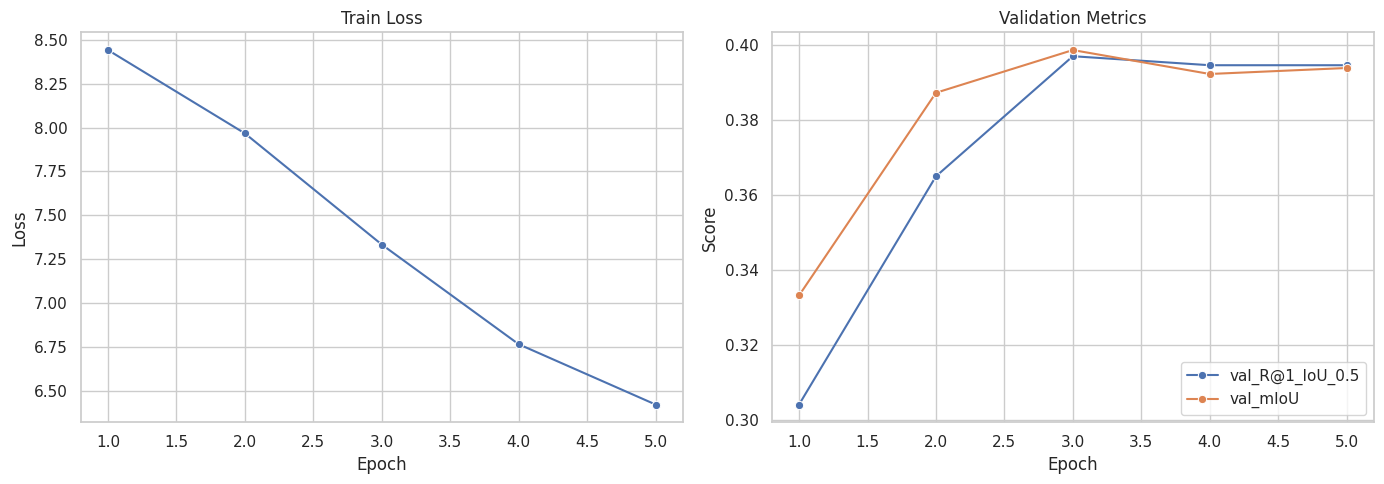

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style='whitegrid')
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=history_df, x='epoch', y='train_loss', marker='o', ax=axes[0], label='train_loss')
sns.lineplot(data=history_df, x='epoch', y='val_loss', marker='o', ax=axes[0], label='val_loss')
axes[0].set_title('Train vs Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

sns.lineplot(data=history_df, x='epoch', y='R@1_IoU_0.5', marker='o', ax=axes[1], label='val_R@1_IoU_0.5')
sns.lineplot(data=history_df, x='epoch', y='mIoU', marker='o', ax=axes[1], label='val_mIoU')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

fig.tight_layout()
plot_path = TRAIN_RUN_DIR / 'training_curves.png'
fig.savefig(plot_path, dpi=200, bbox_inches='tight')
print('saved plot to', plot_path)


In [ ]:
best_checkpoint = CHECKPOINT_DIR / 'best.pt'
if best_checkpoint.exists():
    model.load_state_dict(torch.load(best_checkpoint, map_location=DEVICE))
else:
    raise FileNotFoundError(f'Missing best checkpoint: {best_checkpoint}')

test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=12,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=collate_batch,
)

test_metrics, test_records = run_eval(model, test_loader, collect_records=True)
qual_records = test_records
print(json.dumps(test_metrics, indent=2))

with open(TRAIN_RUN_DIR / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)
with open(TRAIN_RUN_DIR / 'test_records.json', 'w') as f:
    json.dump(test_records, f, indent=2)

shutil.copy2(best_checkpoint, TRAIN_RUN_DIR / 'best.pt')
shutil.copy2(CHECKPOINT_DIR / 'last.pt', TRAIN_RUN_DIR / 'last.pt')

print('saved test metrics to', TRAIN_RUN_DIR / 'test_metrics.json')
print('saved full test records to', TRAIN_RUN_DIR / 'test_records.json')
print('best checkpoint loaded from', best_checkpoint)


eval:   0%|          | 0/233 [00:00<?, ?it/s]

{
  "mIoU": 0.39498783829117334,
  "R@1_IoU_0.3": 0.5989247311827957,
  "R@1_IoU_0.5": 0.4021505376344086,
  "R@1_IoU_0.7": 0.19811827956989247
}
saved test metrics to /content/drive/MyDrive/momentlens_runs/train_20260430_061629/test_metrics.json
best checkpoint loaded from /content/momentlens_train/checkpoints/best.pt


In [ ]:
import json
import math
import random
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import cv2
import numpy as np

QUAL_ROOT = TRAIN_RUN_DIR / "qualitative_examples"
QUAL_ROOT.mkdir(parents=True, exist_ok=True)

records = qual_records if "qual_records" in globals() else records

rng = random.Random(42)
np_rng = np.random.default_rng(42)

def weighted_sample(pool, target, n, used):
    """
    Sample n records from pool with preference around target IoU.
    This keeps values near the target but allows natural variation.
    """
    candidates = [r for r in pool if r["sample_idx"] not in used]
    if not candidates:
        return []

    temperature = 0.12
    scores = np.array([abs(r["iou"] - target) for r in candidates], dtype=np.float32)
    weights = np.exp(-scores / temperature)
    weights = weights / weights.sum()

    picked = []
    available = candidates[:]
    available_weights = weights[:]

    for _ in range(min(n, len(available))):
        idx = int(np_rng.choice(len(available), p=available_weights))
        rec = available.pop(idx)
        available_weights = np.delete(available_weights, idx)
        if available_weights.size > 0:
            available_weights = available_weights / available_weights.sum()
        picked.append(rec)
        used.add(rec["sample_idx"])

    return picked

def choose_examples_around_targets(records):
    used = set()

    low_pool = [r for r in records if 0.00 <= r["iou"] <= 0.30]
    mid_pool = [r for r in records if 0.30 <= r["iou"] <= 0.70]
    high_pool = [r for r in records if 0.70 <= r["iou"] <= 1.00]

    low = weighted_sample(low_pool, target=0.10, n=5, used=used)
    mid = weighted_sample(mid_pool, target=0.50, n=5, used=used)
    high = weighted_sample(high_pool, target=0.90, n=5, used=used)

    def fill(group, target):
        if len(group) >= 5:
            return group[:5]
        remaining = [r for r in records if r["sample_idx"] not in used]
        remaining = sorted(remaining, key=lambda r: abs(r["iou"] - target))
        for rec in remaining:
            group.append(rec)
            used.add(rec["sample_idx"])
            if len(group) == 5:
                break
        return group[:5]

    low = fill(low, 0.10)
    mid = fill(mid, 0.50)
    high = fill(high, 0.90)

    return {
        "low": low,
        "mid": mid,
        "high": high,
    }

def write_video_clip(src_path, out_path, start_sec, end_sec, pad_sec=0.5):
    src_path = Path(src_path)
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists():
        out_path.unlink()

    cap = cv2.VideoCapture(str(src_path))
    if not cap.isOpened():
        raise RuntimeError(f"Unable to open video: {src_path}")

    fps = float(cap.get(cv2.CAP_PROP_FPS) or CONFIG["model_sampling_fps"])
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    if width <= 0 or height <= 0:
        cap.release()
        raise RuntimeError(f"Invalid frame size for: {src_path}")

    start_sec = max(0.0, float(start_sec) - pad_sec)
    end_sec = float(end_sec) + pad_sec
    start_frame = max(0, int(math.floor(start_sec * fps)))
    end_frame = int(math.ceil(end_sec * fps))
    if frame_count > 0:
        end_frame = min(end_frame, frame_count - 1)

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    writer = cv2.VideoWriter(
        str(out_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )

    current = start_frame
    while current <= end_frame:
        ok, frame = cap.read()
        if not ok:
            break
        writer.write(frame)
        current += 1

    cap.release()
    writer.release()

def save_timeline_plot(record, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10, 2.4))
    max_time = max(record["actual_duration"], record["gt_end"], record["pred_end"]) + 0.5
    ax.axvspan(0, max_time, color="lightgray", alpha=0.12)
    ax.axvspan(record["gt_start"], record["gt_end"], color="tab:green", alpha=0.35, label="GT")
    ax.axvspan(record["pred_start"], record["pred_end"], color="tab:orange", alpha=0.35, label="Pred")
    ax.set_xlim(0, max_time)
    ax.set_yticks([])
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{record['group']} | {record['video_id']} | IoU={record['iou']:.3f}")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

groups = choose_examples_around_targets(records)
summary = {k: len(v) for k, v in groups.items()}

with open(TRAIN_RUN_DIR / "qualitative_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

for group, group_records in groups.items():
    group_dir = QUAL_ROOT / group
    group_dir.mkdir(parents=True, exist_ok=True)

    for rank, record in enumerate(group_records, 1):
        case_id = f"{record['sample_id']}_{rank:02d}"
        case_dir = group_dir / case_id
        case_dir.mkdir(parents=True, exist_ok=True)

        src_video = Path(video_files[record["video_id"]])
        shutil.copy2(src_video, case_dir / "original.mp4")
        write_video_clip(src_video, case_dir / "gt_clip.mp4", record["gt_start"], record["gt_end"], pad_sec=0.5)
        write_video_clip(src_video, case_dir / "pred_clip.mp4", record["pred_start"], record["pred_end"], pad_sec=0.5)
        save_timeline_plot({**record, "group": group}, case_dir / "timeline.png")

        metadata = {
            **record,
            "group": group,
            "rank_in_group": rank,
            "video_path": str(src_video),
        }
        with open(case_dir / "metadata.json", "w") as f:
            json.dump(metadata, f, indent=2)

print(json.dumps(summary, indent=2))
print("saved qualitative examples to", QUAL_ROOT)


{
  "low": 5,
  "mid": 5,
  "high": 5
}
saved qualitative examples to /content/drive/MyDrive/momentlens_runs/train_20260430_061629/qualitative_examples


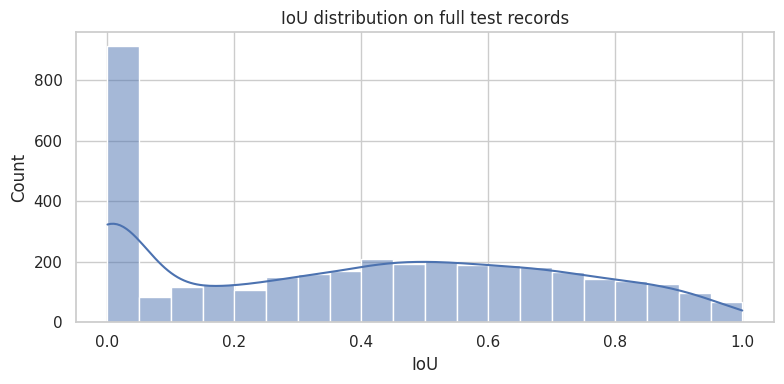

{
  "num_records": 3720,
  "iou_min": 0.0,
  "iou_max": 1.0,
  "iou_mean": 0.3949878381198188,
  "iou_median": 0.40918258190501683
}

Bucket counts:
iou_bucket  count
     0-0.1    995
   0.1-0.3    498
   0.3-0.5    735
   0.5-0.7    758
   0.7-0.9    573
   0.9-1.0    161

Worst 10:


,sample_idx,video_id,iou,gt_start,gt_end,pred_start,pred_end,query
3315,3315,D6MZ4,0.0,0.7,10.2,16.666666,22.000000,person takes a drink from a glass.
1197,1197,5EEXF,0.0,1.0,7.0,20.333334,32.333332,person opens a closet door.
1198,1198,5EEXF,0.0,16.9,23.8,4.000000,13.333333,person puts the towel away.
1206,1206,XRU9O,0.0,8.7,21.9,0.666667,5.333333,a person is standing against a wall eating a s...
3079,3079,14HG1,0.0,16.1,21.7,24.666666,30.666666,person sits on the floor.
3084,3084,QBUAT,0.0,8.6,15.8,17.000000,23.000000,the person takes a blanket from the cabinet.
3085,3085,QBUAT,0.0,0.0,9.7,18.000000,23.000000,person begins to undress.
1685,1685,N6FZ7,0.0,0.0,6.4,12.666667,18.000000,person runs over to use a vacuum.
1687,1687,9YOI8,0.0,4.8,11.9,14.666667,31.000000,person opening a window.
1698,1698,FDDDG,0.0,1.8,6.3,10.000000,14.666667,person takes a phone.



Best 10:


,sample_idx,video_id,iou,gt_start,gt_end,pred_start,pred_end,query
71,71,1CYLM,1.000000,0.0,14.0,0.0,14.000000,the person is drinking something from a cup.
3195,3195,WEW2E,1.000000,0.0,8.0,0.0,8.000000,a person walks in the entryway holding a bag.
2826,2826,LKH9A,1.000000,0.0,6.0,0.0,6.000000,person turns on the light.
1509,1509,WP5RH,1.000000,0.0,8.0,0.0,8.000000,a person runs through a doorway.
1511,1511,WP5RH,1.000000,0.0,8.0,0.0,8.000000,a person is running in place under a doorway.
2352,2352,XHN6Y,0.996564,0.0,9.7,0.0,9.666667,a person is cooking something on the stove.
1918,1918,OTUV7,0.994737,0.0,6.3,0.0,6.333333,a person is in a office eating food.
1845,1845,ZTWJB,0.993750,0.0,5.3,0.0,5.333333,a person throws a broom ferociously at the floor.
70,70,1CYLM,0.990698,0.0,14.2,0.0,14.333333,a person sits down on a couch.
2285,2285,YLEEO,0.989583,0.0,6.4,0.0,6.333333,a person closes a door.



Closest to 0.5:


,sample_idx,video_id,iou,gt_start,gt_end,pred_start,pred_end,query
3414,3414,C1DK7,0.500000,22.5,28.000,21.000000,26.000000,person closing the door.
3412,3412,C1DK7,0.500000,22.5,28.000,21.000000,26.000000,person leaves closing door behind them.
967,967,TH3M0,0.500000,18.8,25.800,18.000000,32.000000,person sits on a chair.
364,364,759MY,0.500000,1.8,6.800,0.000000,10.000000,a person awakens in their home office.
3318,3318,LG7WK,0.500000,0.0,3.500,0.333333,6.333333,a person lays on a floor.
3316,3316,LG7WK,0.500000,0.0,3.500,0.333333,6.333333,a person laying on a floor.
2652,2652,OWUW8,0.500000,0.5,5.000,0.333333,9.333333,person throws it down to the floor.
3191,3191,ZPRJH,0.500000,8.5,17.000,6.666667,13.666667,person looking at various books on a shelf.
3420,3420,STHIK,0.500000,1.9,7.200,0.333333,5.333333,person drinking a cup of coffee.
216,216,U2AO1,0.499976,10.5,16.667,9.666667,14.000000,person starts eating.



Saved survey files to: /content/drive/MyDrive/momentlens_runs/train_20260430_061629/iou_survey


In [ ]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if "qual_records" in globals():
    recs = qual_records
elif "test_records" in globals():
    recs = test_records
else:
    raise NameError("Missing full test records. Expected `qual_records` or `test_records` in memory.")

df = pd.DataFrame(recs)

if len(df) <= 20:
    raise ValueError(f"Looks like only {len(df)} records are loaded. Use the full test records from cell 28, not the selected 5 examples.")

survey_dir = TRAIN_RUN_DIR / "iou_survey"
survey_dir.mkdir(parents=True, exist_ok=True)

summary = {
    "num_records": int(len(df)),
    "iou_min": float(df["iou"].min()),
    "iou_max": float(df["iou"].max()),
    "iou_mean": float(df["iou"].mean()),
    "iou_median": float(df["iou"].median()),
}

bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ["0-0.1", "0.1-0.3", "0.3-0.5", "0.5-0.7", "0.7-0.9", "0.9-1.0"]
df["iou_bucket"] = pd.cut(df["iou"], bins=bins, labels=labels, include_lowest=True)

bucket_counts = df["iou_bucket"].value_counts().sort_index().reset_index()
bucket_counts.columns = ["iou_bucket", "count"]

df["dist_to_05"] = (df["iou"] - 0.5).abs()

df.to_csv(survey_dir / "iou_survey_records.csv", index=False)
bucket_counts.to_csv(survey_dir / "iou_bucket_counts.csv", index=False)
with open(survey_dir / "iou_survey_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))
sns.histplot(df["iou"], bins=20, kde=True)
plt.title("IoU distribution on full test records")
plt.xlabel("IoU")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(survey_dir / "iou_hist.png", dpi=200, bbox_inches="tight")
plt.show()

print(json.dumps(summary, indent=2))
print("\nBucket counts:")
print(bucket_counts.to_string(index=False))

print("\nWorst 10:")
display(df.sort_values("iou", ascending=True).head(10)[
    ["sample_idx", "video_id", "iou", "gt_start", "gt_end", "pred_start", "pred_end", "query"]
])

print("\nBest 10:")
display(df.sort_values("iou", ascending=False).head(10)[
    ["sample_idx", "video_id", "iou", "gt_start", "gt_end", "pred_start", "pred_end", "query"]
])

print("\nClosest to 0.5:")
display(df.sort_values("dist_to_05", ascending=True).head(10)[
    ["sample_idx", "video_id", "iou", "gt_start", "gt_end", "pred_start", "pred_end", "query"]
])

print("\nSaved survey files to:", survey_dir)
